# Investment Risk Profile: Data Study

This notebook studies the static raw dataset in `data/raw/synthetic_risk_profiles.csv`. Run cells from top to bottom: inspect the raw data, clean missing values, explore relationships, flag outliers, and save the prepared CSV for model training.

The source is educational synthetic data, so the charts demonstrate analysis techniques rather than financial advice.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
np.random.seed(42)

DATA_DIRECTORY = Path.cwd()
if not (DATA_DIRECTORY / "raw" / "synthetic_risk_profiles.csv").exists():
    DATA_DIRECTORY = Path.cwd() / "data"

RAW_DATA_PATH = DATA_DIRECTORY / "raw" / "synthetic_risk_profiles.csv"
PROCESSED_DATA_PATH = DATA_DIRECTORY / "processed" / "risk_profiles_clean.csv"
REPORT_DIRECTORY = DATA_DIRECTORY / "reports"
REPORT_DIRECTORY.mkdir(parents=True, exist_ok=True)

NUMERIC_COLUMNS = [
    "age", "monthly_income", "monthly_expenses", "monthly_surplus", "savings",
    "existing_investments", "monthly_emi", "investment_horizon",
    "investment_experience", "reaction_to_market_loss", "risk_questionnaire_score",
]
CATEGORICAL_COLUMNS = ["investment_frequency", "liquidity_preference", "investment_goal"]
RISK_ORDER = ["LOW", "MEDIUM", "HIGH"]

In [5]:
# Load dataset and inspect its basic structure
raw_dataset = pd.read_csv(RAW_DATA_PATH)

display(raw_dataset.head())
display(raw_dataset.tail())
display(raw_dataset.sample(5, random_state=42))

print(f"Shape: {raw_dataset.shape}")
print("\nColumns:", raw_dataset.columns.tolist())
print("\nIndex:", raw_dataset.index)
raw_dataset.info()

,age,monthly_income,monthly_expenses,monthly_surplus,savings,existing_investments,monthly_emi,investment_horizon,investment_experience,reaction_to_market_loss,investment_frequency,liquidity_preference,investment_goal,risk_questionnaire_score,risk_profile
0,61,"50,000.00","41,500.00",NaN,982000,"405,000.00",14300,17,3,1,MONTHLY,MEDIUM,WEALTH_CREATION,70.00,HIGH
1,45,"109,000.00","59,500.00","15,800.00",1865000,NaN,33700,5,1,2,MONTHLY,MEDIUM,TAX_SAVING,47.00,HIGH
2,34,"113,000.00","67,200.00","8,400.00",939000,"422,000.00",37400,1,4,4,MONTHLY,LOW,SHORT_TERM_GOAL,94.00,MEDIUM
3,34,"84,000.00","43,300.00","31,300.00",976000,"357,000.00",9400,14,2,1,MONTHLY,HIGH,RETIREMENT,NaN,HIGH
4,21,"80,000.00","65,500.00",0.00,67000,"20,000.00",32600,2,3,4,QUARTERLY,NaN,RETIREMENT,77.00,MEDIUM


,age,monthly_income,monthly_expenses,monthly_surplus,savings,existing_investments,monthly_emi,investment_horizon,investment_experience,reaction_to_market_loss,investment_frequency,liquidity_preference,investment_goal,risk_questionnaire_score,risk_profile
4995,36,"76,000.00","36,300.00","18,100.00",1357000,"569,000.00",21600,2,1,4,MONTHLY,HIGH,TAX_SAVING,60.00,HIGH
4996,57,"96,000.00","51,800.00","17,800.00",1048000,"262,000.00",26400,16,2,2,RARELY,LOW,SHORT_TERM_GOAL,61.00,HIGH
4997,64,"110,000.00","101,200.00",0.00,2187000,"477,000.00",11000,9,1,4,MONTHLY,MEDIUM,EMERGENCY_FUND,71.00,HIGH
4998,56,"53,000.00","40,200.00",0.00,314000,"177,000.00",27400,3,2,4,MONTHLY,MEDIUM,RETIREMENT,66.00,MEDIUM
4999,40,"33,000.00","26,500.00",0.00,51000,"15,000.00",11400,2,1,1,MONTHLY,LOW,TAX_SAVING,48.00,LOW


,age,monthly_income,monthly_expenses,monthly_surplus,savings,existing_investments,monthly_emi,investment_horizon,investment_experience,reaction_to_market_loss,investment_frequency,liquidity_preference,investment_goal,risk_questionnaire_score,risk_profile
1501,37,"48,000.00","32,700.00",0.00,654000,"412,000.00",18600,9,4,4,RARELY,HIGH,TAX_SAVING,71.00,HIGH
2586,21,"49,000.00","43,700.00",0.00,274000,"103,000.00",24800,17,3,5,RARELY,MEDIUM,EMERGENCY_FUND,82.00,LOW
2653,46,"95,000.00","53,900.00","31,300.00",1385000,"256,000.00",9800,12,1,4,RARELY,HIGH,EMERGENCY_FUND,40.00,MEDIUM
1055,38,"86,000.00","41,800.00","28,800.00",105000,"17,000.00",15400,10,4,4,LUMP_SUM,MEDIUM,RETIREMENT,88.00,HIGH
705,56,"51,000.00","30,500.00","10,800.00",534000,"252,000.00",9700,8,3,1,LUMP_SUM,HIGH,WEALTH_CREATION,33.00,MEDIUM


Shape: (5000, 15)

Columns: ['age', 'monthly_income', 'monthly_expenses', 'monthly_surplus', 'savings', 'existing_investments', 'monthly_emi', 'investment_horizon', 'investment_experience', 'reaction_to_market_loss', 'investment_frequency', 'liquidity_preference', 'investment_goal', 'risk_questionnaire_score', 'risk_profile']

Index: RangeIndex(start=0, stop=5000, step=1)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       5000 non-null   int64  
 1   monthly_income            4999 non-null   float64
 2   monthly_expenses          4999 non-null   float64
 3   monthly_surplus           4999 non-null   float64
 4   savings                   5000 non-null   int64  
 5   existing_investments      4999 non-null   float64
 6   monthly_emi               5000 non-null   int64  
 7   investment_horizon

In [6]:
# Data types, memory use, summary statistics, quantiles, and category frequencies
print(raw_dataset.dtypes)
print("\nMemory usage (bytes):")
display(raw_dataset.memory_usage(deep=True).to_frame("bytes"))

typed_dataset = raw_dataset.copy()
for column in NUMERIC_COLUMNS:
    typed_dataset[column] = pd.to_numeric(typed_dataset[column], errors="coerce")
for column in CATEGORICAL_COLUMNS + ["risk_profile"]:
    typed_dataset[column] = typed_dataset[column].astype("category")

display(typed_dataset.describe(include="all").T)
display(typed_dataset[NUMERIC_COLUMNS].median().to_frame("median"))
for column in CATEGORICAL_COLUMNS + ["risk_profile"]:
    print(f"\n{column}: {typed_dataset[column].nunique()} unique values")
    display(typed_dataset[column].value_counts(dropna=False).to_frame("count"))

display(typed_dataset[NUMERIC_COLUMNS].quantile([0.01, 0.25, 0.5, 0.75, 0.99]).T)

age                           int64
monthly_income              float64
monthly_expenses            float64
monthly_surplus             float64
savings                       int64
existing_investments        float64
monthly_emi                   int64
investment_horizon            int64
investment_experience         int64
reaction_to_market_loss       int64
investment_frequency         object
liquidity_preference         object
investment_goal              object
risk_questionnaire_score    float64
risk_profile                 object
dtype: object

Memory usage (bytes):


,bytes
Index,128
age,40000
monthly_income,40000
monthly_expenses,40000
monthly_surplus,40000
savings,40000
existing_investments,40000
monthly_emi,40000
investment_horizon,40000
investment_experience,40000


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,"5,000.00",NaN,NaN,NaN,43.33,13.10,21.00,32.00,44.00,55.00,65.00
monthly_income,"4,999.00",NaN,NaN,NaN,"76,831.57","45,035.57","20,000.00","45,000.00","66,000.00","97,000.00","400,000.00"
monthly_expenses,"4,999.00",NaN,NaN,NaN,"47,722.16","31,230.15","4,200.00","26,000.00","40,100.00","60,600.00","328,100.00"
monthly_surplus,"4,999.00",NaN,NaN,NaN,"15,166.53","17,580.20",0.00,"2,100.00","10,400.00","21,400.00","181,400.00"
savings,"5,000.00",NaN,NaN,NaN,"977,398.80","975,637.79","4,000.00","348,750.00","683,000.00","1,254,250.00","10,972,000.00"
existing_investments,"4,999.00",NaN,NaN,NaN,"261,216.04","349,606.31",0.00,"58,500.00","145,000.00","319,000.00","4,142,000.00"
monthly_emi,"5,000.00",NaN,NaN,NaN,"15,509.28","14,077.59",0.00,"5,900.00","11,500.00","20,625.00","159,200.00"
investment_horizon,"5,000.00",NaN,NaN,NaN,9.01,6.00,1.00,4.00,8.00,13.00,25.00
investment_experience,"5,000.00",NaN,NaN,NaN,2.28,1.22,1.00,1.00,2.00,3.00,5.00
reaction_to_market_loss,"5,000.00",NaN,NaN,NaN,2.77,1.28,1.00,2.00,3.00,4.00,5.00


,median
age,44.00
monthly_income,"66,000.00"
monthly_expenses,"40,100.00"
monthly_surplus,"10,400.00"
savings,"683,000.00"
existing_investments,"145,000.00"
monthly_emi,"11,500.00"
investment_horizon,8.00
investment_experience,2.00
reaction_to_market_loss,3.00



investment_frequency: 4 unique values


...


investment_goal: 5 unique values


,count
investment_goal,
WEALTH_CREATION,1762
RETIREMENT,1025
EMERGENCY_FUND,766
TAX_SAVING,730
SHORT_TERM_GOAL,716
NaN,1



risk_profile: 3 unique values


,count
risk_profile,
HIGH,3501
MEDIUM,952
LOW,547


,0.01,0.25,0.50,0.75,0.99
age,21.00,32.00,44.00,55.00,65.00
monthly_income,"20,000.00","45,000.00","66,000.00","97,000.00","232,000.00"
monthly_expenses,"9,800.00","26,000.00","40,100.00","60,600.00","157,002.00"
monthly_surplus,0.00,"2,100.00","10,400.00","21,400.00","80,558.00"
savings,"51,990.00","348,750.00","683,000.00","1,254,250.00","4,850,070.00"
existing_investments,"4,000.00","58,500.00","145,000.00","319,000.00","1,670,000.00"
monthly_emi,799.00,"5,900.00","11,500.00","20,625.00","66,800.00"
investment_horizon,1.00,4.00,8.00,13.00,23.00
investment_experience,1.00,1.00,2.00,3.00,5.00
reaction_to_market_loss,1.00,2.00,3.00,4.00,5.00


,missing_count,missing_percent
monthly_income,1,0.02
monthly_expenses,1,0.02
monthly_surplus,1,0.02
existing_investments,1,0.02
investment_frequency,1,0.02
liquidity_preference,1,0.02
investment_goal,1,0.02
risk_questionnaire_score,1,0.02


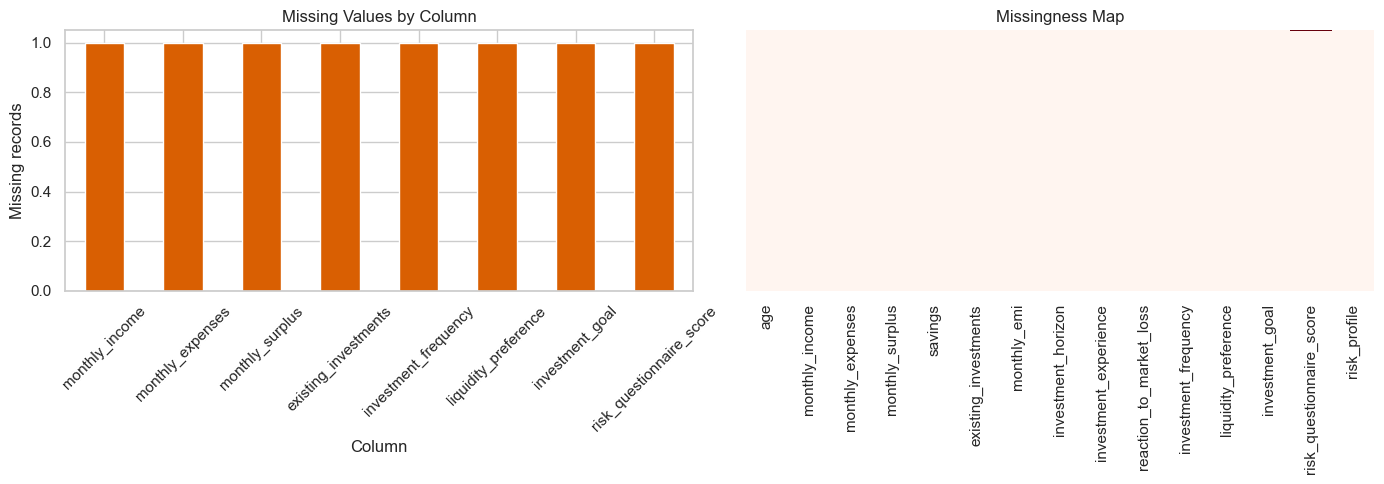

Missing-value handling complete. Remaining missing values: 0


In [7]:
# Missing-value audit and visualization
missing_summary = pd.DataFrame({
    "missing_count": typed_dataset.isna().sum(),
    "missing_percent": typed_dataset.isna().mean().mul(100),
}).query("missing_count > 0").sort_values("missing_count", ascending=False)
display(missing_summary)

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
missing_summary["missing_count"].plot.bar(ax=axes[0], color="#d95f02")
axes[0].set(title="Missing Values by Column", xlabel="Column", ylabel="Missing records")
axes[0].tick_params(axis="x", rotation=45)
sns.heatmap(typed_dataset.isna(), cbar=False, yticklabels=False, cmap="Reds", ax=axes[1])
axes[1].set_title("Missingness Map")
plt.tight_layout()
plt.show()

# Cleaning configuration: numeric median; categorical most-frequent value.
cleaned_dataset = typed_dataset.copy()
for column in NUMERIC_COLUMNS:
    cleaned_dataset[column] = cleaned_dataset[column].fillna(cleaned_dataset[column].median())
for column in CATEGORICAL_COLUMNS:
    cleaned_dataset[column] = cleaned_dataset[column].astype("string").str.strip().str.upper()
    cleaned_dataset[column] = cleaned_dataset[column].fillna(cleaned_dataset[column].mode().iat[0])

cleaned_dataset["risk_profile"] = cleaned_dataset["risk_profile"].astype("string").str.strip().str.upper()
cleaned_dataset = cleaned_dataset[cleaned_dataset["risk_profile"].isin(RISK_ORDER)].copy()
cleaned_dataset["monthly_surplus"] = (
    cleaned_dataset["monthly_income"] - cleaned_dataset["monthly_expenses"] - cleaned_dataset["monthly_emi"]
).clip(lower=0)
assert not cleaned_dataset.isna().any().any(), "Missing values remain after cleaning"
print("Missing-value handling complete. Remaining missing values:", cleaned_dataset.isna().sum().sum())

In [8]:
# Duplicate and constant-feature checks
print("Exact duplicate rows:", cleaned_dataset.duplicated().sum())
without_duplicates = cleaned_dataset.drop_duplicates().copy()
constant_columns = without_duplicates.columns[without_duplicates.nunique(dropna=False).eq(1)].tolist()
dominant_value_share = without_duplicates.apply(
    lambda column: column.value_counts(dropna=False, normalize=True).iat[0]
)
near_constant_columns = dominant_value_share[dominant_value_share.ge(0.99)].index.tolist()
print("Constant columns:", constant_columns or "none")
print("Near-constant columns (>=99% one value):", near_constant_columns or "none")

# Keep the full cleaned dataset because no exact duplicates were found.
dataset = cleaned_dataset.copy()
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
dataset.to_csv(PROCESSED_DATA_PATH, index=False)
print(f"Saved clean data to: {PROCESSED_DATA_PATH}")

Exact duplicate rows: 0
Constant columns: none
Near-constant columns (>=99% one value): none
Saved clean data to: /Users/fc20386/Vs_code_Practice/investmentAI/data/processed/risk_profiles_clean.csv


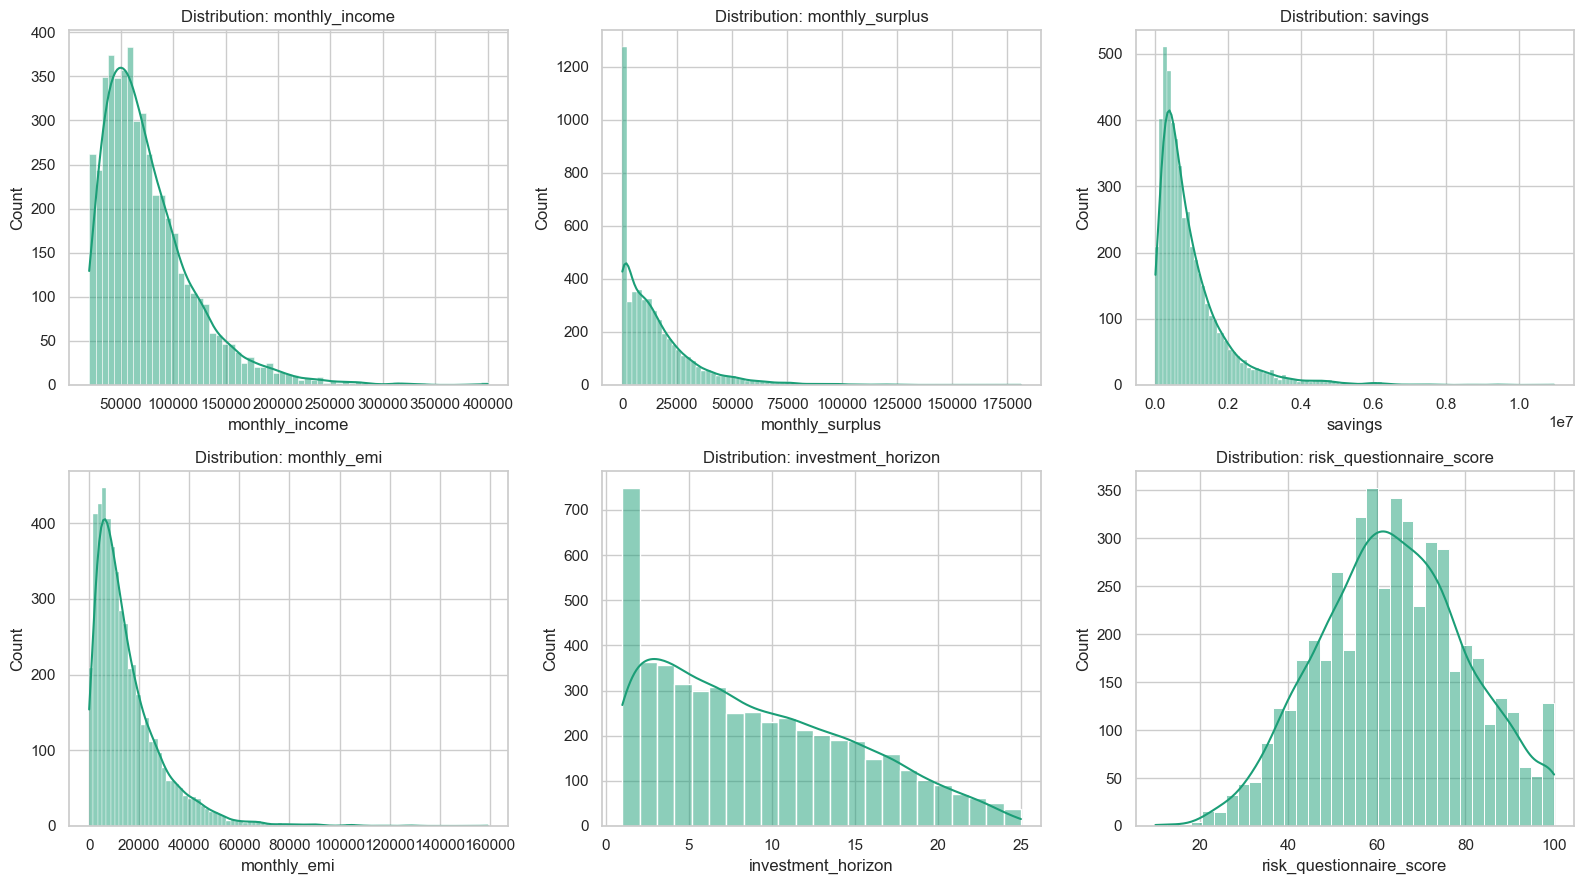

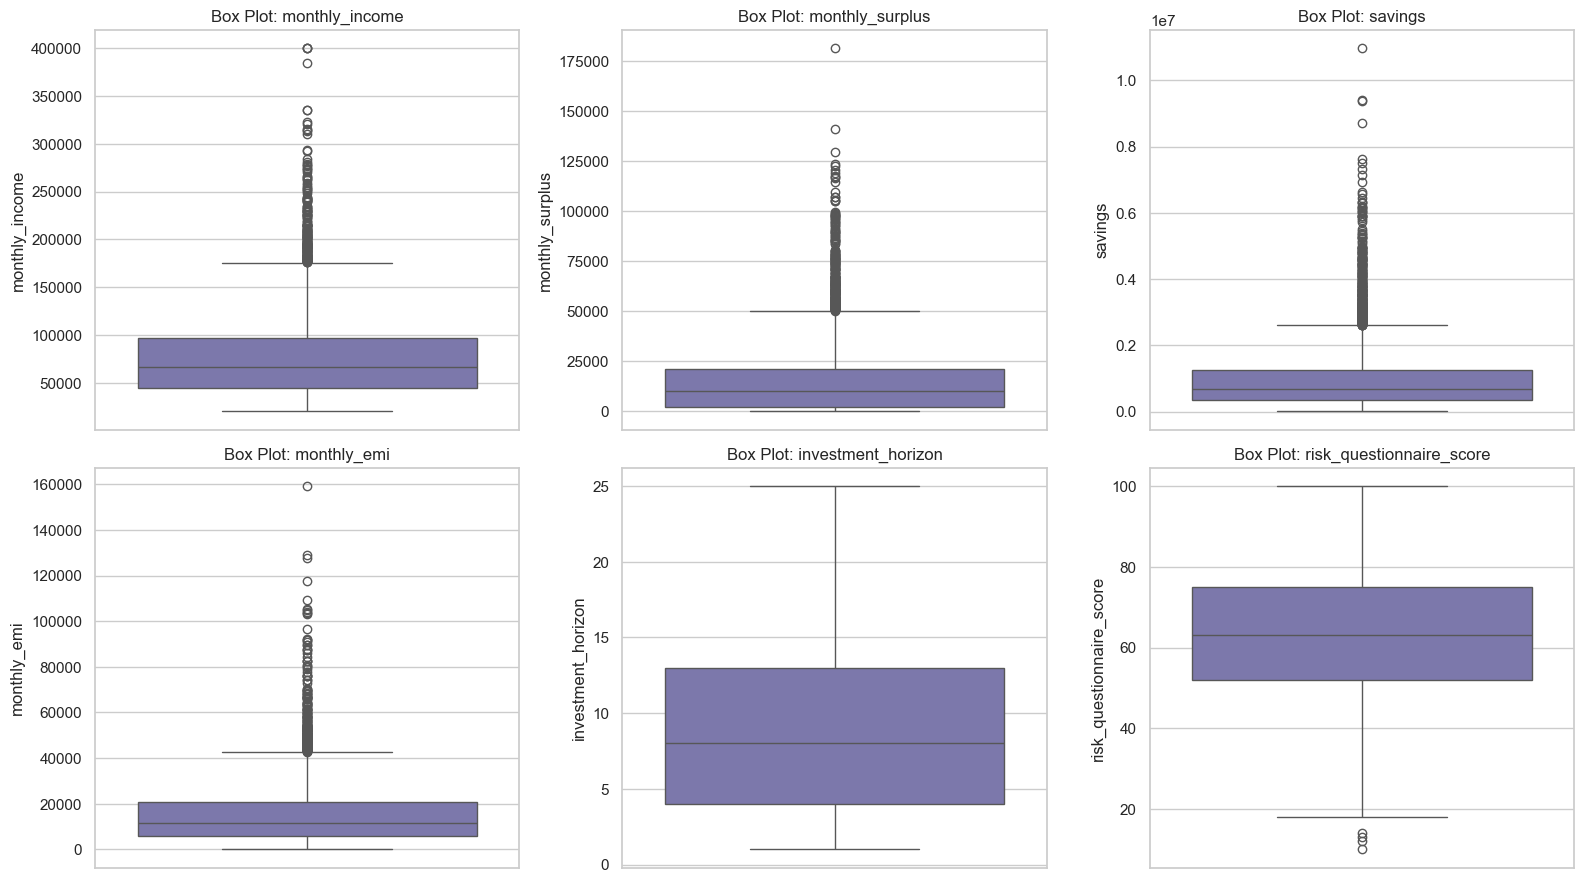

In [9]:
# Univariate numeric analysis: histograms, KDE curves, and box plots
plot_columns = ["monthly_income", "monthly_surplus", "savings", "monthly_emi", "investment_horizon", "risk_questionnaire_score"]
figure, axes = plt.subplots(2, 3, figsize=(16, 9))
for axis, column in zip(axes.flat, plot_columns):
    sns.histplot(dataset[column], kde=True, ax=axis, color="#1b9e77")
    axis.set_title(f"Distribution: {column}")
plt.tight_layout()
plt.show()

figure, axes = plt.subplots(2, 3, figsize=(16, 9))
for axis, column in zip(axes.flat, plot_columns):
    sns.boxplot(y=dataset[column], ax=axis, color="#7570b3")
    axis.set_title(f"Box Plot: {column}")
plt.tight_layout()
plt.show()


investment_frequency (%):


,percentage
investment_frequency,
MONTHLY,48.00
RARELY,19.56
LUMP_SUM,17.50
QUARTERLY,14.94



liquidity_preference (%):


,percentage
liquidity_preference,
MEDIUM,44.84
HIGH,29.68
LOW,25.48



investment_goal (%):


...

risk_profile,HIGH,LOW,MEDIUM
investment_frequency,,,
LUMP_SUM,68.10,12.90,19.00
MONTHLY,74.60,8.00,17.30
QUARTERLY,73.60,7.90,18.50
RARELY,57.70,18.60,23.70



Risk profile composition by liquidity_preference (%):


risk_profile,HIGH,LOW,MEDIUM
liquidity_preference,,,
HIGH,58.40,16.40,25.30
LOW,82.30,6.10,11.50
MEDIUM,70.70,10.10,19.20



Risk profile composition by investment_goal (%):


risk_profile,HIGH,LOW,MEDIUM
investment_goal,,,
EMERGENCY_FUND,49.90,24.40,25.70
RETIREMENT,76.90,6.60,16.50
SHORT_TERM_GOAL,57.00,18.60,24.40
TAX_SAVING,70.80,9.90,19.30
WEALTH_CREATION,79.80,4.90,15.30


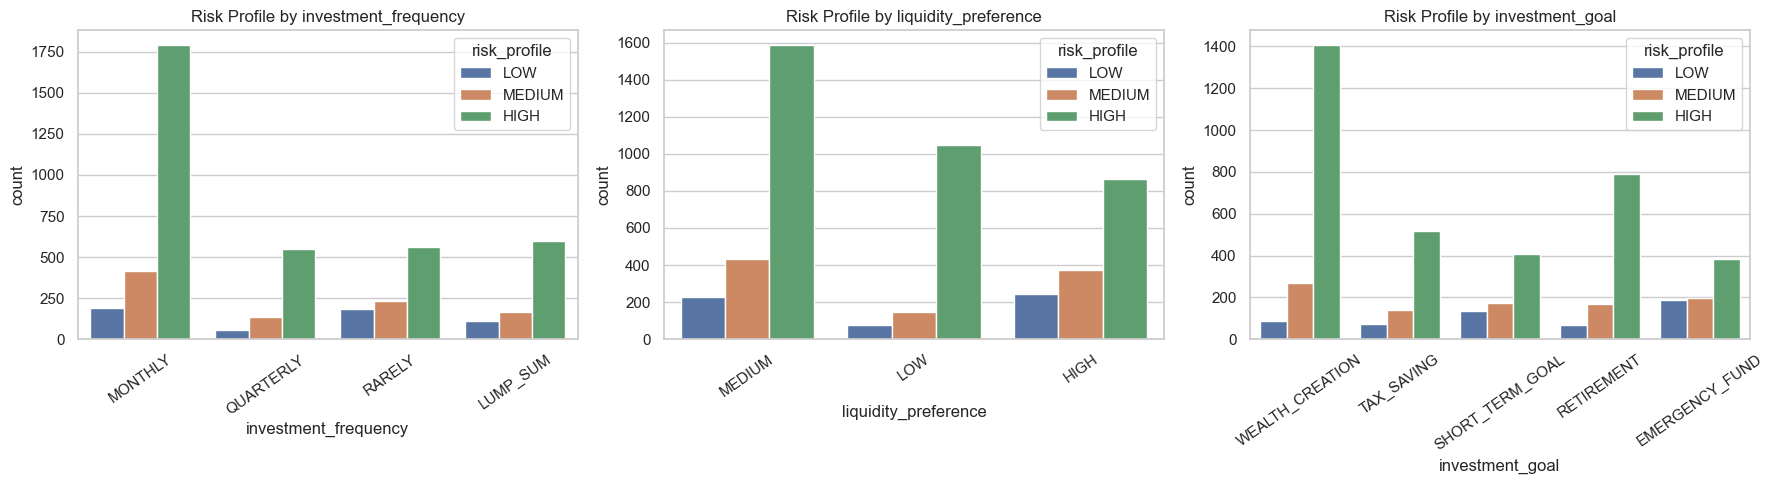

In [10]:
# Categorical analysis: proportions, grouped frequencies, and count plots
for column in CATEGORICAL_COLUMNS + ["risk_profile"]:
    proportions = dataset[column].value_counts(normalize=True).mul(100).round(2)
    print(f"\n{column} (%):")
    display(proportions.to_frame("percentage"))

for column in CATEGORICAL_COLUMNS:
    frequency_table = pd.crosstab(dataset[column], dataset["risk_profile"], normalize="index").mul(100).round(1)
    print(f"\nRisk profile composition by {column} (%):")
    display(frequency_table)

figure, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, column in zip(axes, CATEGORICAL_COLUMNS):
    sns.countplot(data=dataset, x=column, hue="risk_profile", hue_order=RISK_ORDER, ax=axis)
    axis.set_title(f"Risk Profile by {column}")
    axis.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

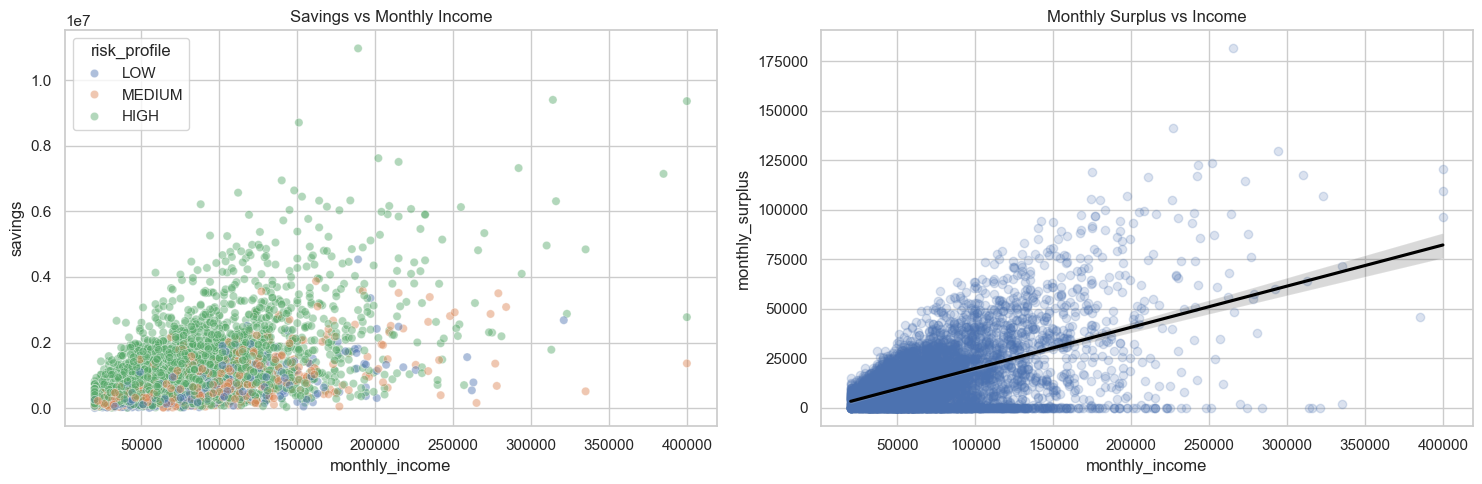

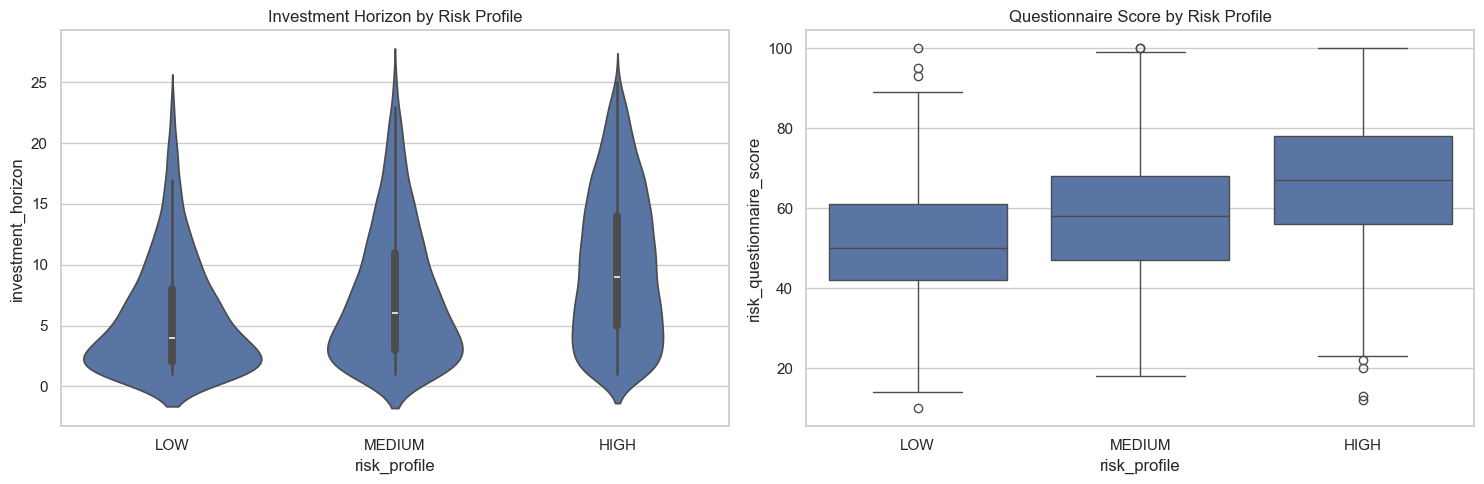

In [11]:
# Bivariate analysis: numeric relationships and class separation
figure, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(
    data=dataset, x="monthly_income", y="savings", hue="risk_profile",
    hue_order=RISK_ORDER, alpha=0.45, ax=axes[0]
)
axes[0].set_title("Savings vs Monthly Income")
sns.regplot(
    data=dataset, x="monthly_income", y="monthly_surplus",
    scatter_kws={"alpha": 0.2}, line_kws={"color": "black"}, ax=axes[1]
)
axes[1].set_title("Monthly Surplus vs Income")
plt.tight_layout()
plt.show()

figure, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.violinplot(data=dataset, x="risk_profile", y="investment_horizon", order=RISK_ORDER, ax=axes[0])
axes[0].set_title("Investment Horizon by Risk Profile")
sns.boxplot(data=dataset, x="risk_profile", y="risk_questionnaire_score", order=RISK_ORDER, ax=axes[1])
axes[1].set_title("Questionnaire Score by Risk Profile")
plt.tight_layout()
plt.show()

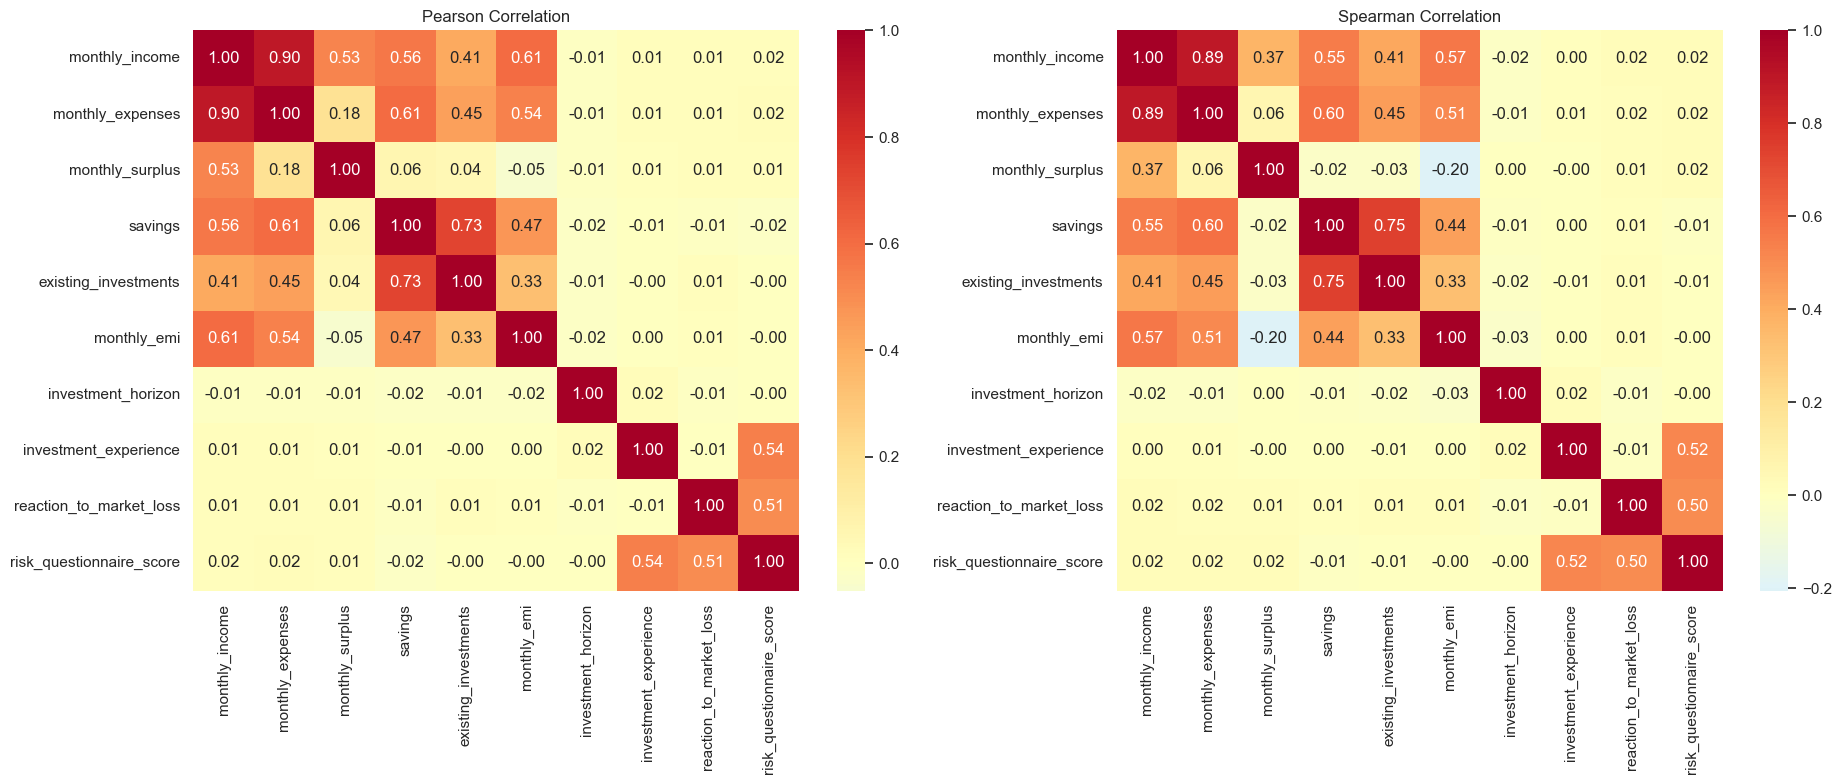

absolute_pearson_correlation
monthly_income           monthly_expenses                                  0.90
monthly_expenses         monthly_income                                    0.90
existing_investments     savings                                           0.73
savings                  existing_investments                              0.73
                         monthly_expenses                                  0.61
monthly_expenses         savings                                           0.61
monthly_emi              monthly_income                                    0.61
monthly_income           monthly_emi                                       0.61
savings                  monthly_income                                    0.56
monthly_income           savings                                           0.56
risk_questionnaire_score investment_experience                             0.54
investment_experience    risk_questionnaire_score                          0.54
monthly_emi              monthly_expenses                                  0.54
monthly_expenses         monthly_emi                                       0.54
monthly_income           monthly_surplus                                   0.53

In [12]:
# Pearson and Spearman correlations with feature screening
correlation_columns = [
    "monthly_income", "monthly_expenses", "monthly_surplus", "savings",
    "existing_investments", "monthly_emi", "investment_horizon",
    "investment_experience", "reaction_to_market_loss", "risk_questionnaire_score",
]
pearson_correlation = dataset[correlation_columns].corr(method="pearson")
spearman_correlation = dataset[correlation_columns].corr(method="spearman")

figure, axes = plt.subplots(1, 2, figsize=(19, 8))
sns.heatmap(pearson_correlation, annot=True, fmt=".2f", center=0, cmap="RdYlBu_r", ax=axes[0])
axes[0].set_title("Pearson Correlation")
sns.heatmap(spearman_correlation, annot=True, fmt=".2f", center=0, cmap="RdYlBu_r", ax=axes[1])
axes[1].set_title("Spearman Correlation")
plt.tight_layout()
plt.show()

absolute_correlations = (
    pearson_correlation.where(~np.eye(len(pearson_correlation), dtype=bool))
    .stack().abs().sort_values(ascending=False).to_frame("absolute_pearson_correlation")
)
display(absolute_correlations.head(15))

,iqr_flag_count,z_score_flag_count
monthly_income,186,78
monthly_expenses,196,88
savings,302,107
existing_investments,399,108
monthly_emi,245,83


Rows with one or more IQR flags: 733


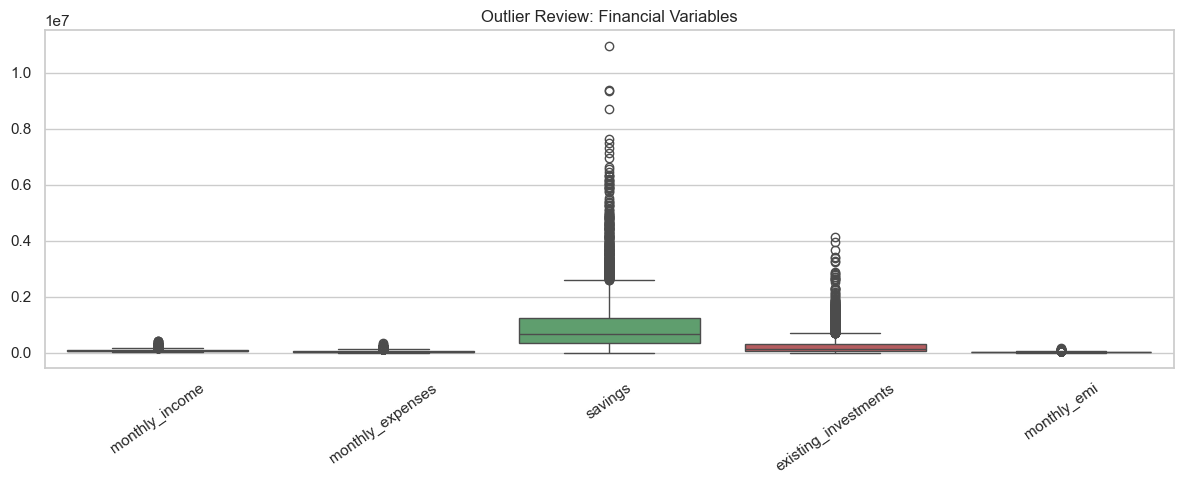

In [13]:
# Outlier detection: IQR and z-score flags (flags are reviewed, not dropped automatically)
outlier_columns = ["monthly_income", "monthly_expenses", "savings", "existing_investments", "monthly_emi"]
quartile_one = dataset[outlier_columns].quantile(0.25)
quartile_three = dataset[outlier_columns].quantile(0.75)
iqr = quartile_three - quartile_one
iqr_flags = (dataset[outlier_columns] < quartile_one - 1.5 * iqr) | (dataset[outlier_columns] > quartile_three + 1.5 * iqr)
z_scores = pd.DataFrame(
    np.abs(stats.zscore(dataset[outlier_columns], nan_policy="omit")),
    columns=outlier_columns,
    index=dataset.index,
)
z_score_flags = z_scores.gt(3)

outlier_summary = pd.DataFrame({
    "iqr_flag_count": iqr_flags.sum(),
    "z_score_flag_count": z_score_flags.sum(),
})
display(outlier_summary)
print("Rows with one or more IQR flags:", iqr_flags.any(axis=1).sum())

figure, axis = plt.subplots(figsize=(12, 5))
sns.boxplot(data=dataset[outlier_columns], ax=axis)
axis.set_title("Outlier Review: Financial Variables")
axis.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
savings_ratio,"5,000.00",NaN,NaN,NaN,1.07,0.77,0.01,0.50,0.88,1.44,6.53
expense_ratio,"5,000.00",NaN,NaN,NaN,0.62,0.16,0.20,0.52,0.62,0.73,0.92
emi_to_income_ratio,"5,000.00",NaN,NaN,NaN,0.20,0.13,0.00,0.10,0.18,0.28,0.55
investment_to_income_ratio,"5,000.00",NaN,NaN,NaN,0.29,0.31,0.00,0.08,0.19,0.39,3.96
log_savings,"5,000.00",NaN,NaN,NaN,13.38,0.96,8.29,12.76,13.43,14.04,16.21
horizon_band,5000,3,LONG,2613,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_loss_tolerance,"5,000.00",NaN,NaN,NaN,6.30,4.74,1.00,3.00,5.00,9.00,25.00
income_z_score,"5,000.00",NaN,NaN,NaN,0.00,1.00,-1.26,-0.71,-0.24,0.45,7.18


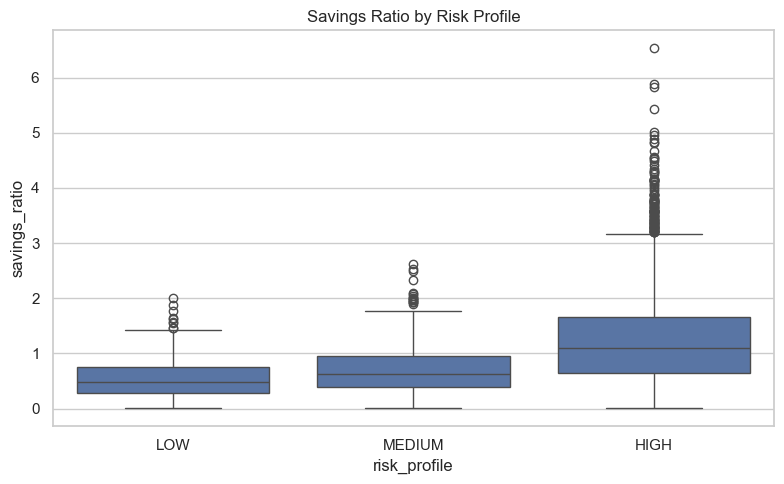

In [14]:
# Feature-engineering sandbox: ratios, log transform, bins, interaction, and scaling
engineered_dataset = dataset.copy()
engineered_dataset["savings_ratio"] = engineered_dataset["savings"] / (engineered_dataset["monthly_income"] * 12)
engineered_dataset["expense_ratio"] = engineered_dataset["monthly_expenses"] / engineered_dataset["monthly_income"]
engineered_dataset["emi_to_income_ratio"] = engineered_dataset["monthly_emi"] / engineered_dataset["monthly_income"]
engineered_dataset["investment_to_income_ratio"] = engineered_dataset["existing_investments"] / (engineered_dataset["monthly_income"] * 12)
engineered_dataset["log_savings"] = np.log1p(engineered_dataset["savings"])
engineered_dataset["horizon_band"] = pd.cut(
    engineered_dataset["investment_horizon"], bins=[0, 2, 7, np.inf], labels=["SHORT", "MEDIUM", "LONG"]
)
engineered_dataset["experience_loss_tolerance"] = (
    engineered_dataset["investment_experience"] * engineered_dataset["reaction_to_market_loss"]
)
engineered_dataset["income_z_score"] = stats.zscore(engineered_dataset["monthly_income"])

display(engineered_dataset[[
    "savings_ratio", "expense_ratio", "emi_to_income_ratio", "investment_to_income_ratio",
    "log_savings", "horizon_band", "experience_loss_tolerance", "income_z_score",
]].describe(include="all").T)

figure, axis = plt.subplots(figsize=(8, 5))
sns.boxplot(data=engineered_dataset, x="risk_profile", y="savings_ratio", order=RISK_ORDER, ax=axis)
axis.set_title("Savings Ratio by Risk Profile")
plt.tight_layout()
plt.show()

In [15]:
# Optional automated HTML report. Uncomment after installing: python3 -m pip install ydata-profiling
# from ydata_profiling import ProfileReport
# profile = ProfileReport(dataset, title="Investment Risk Profile Data Study", explorative=True)
# profile.to_file(REPORT_DIRECTORY / "risk_profile_data_study.html")

print("Notebook study complete.")
print(f"Clean dataset: {PROCESSED_DATA_PATH}")
print(f"Existing batch-report directory: {REPORT_DIRECTORY}")

Notebook study complete.
Clean dataset: /Users/fc20386/Vs_code_Practice/investmentAI/data/processed/risk_profiles_clean.csv
Existing batch-report directory: /Users/fc20386/Vs_code_Practice/investmentAI/data/reports
